# 05 - Hierarchical Concept Analysis & Macro-Clusters

In this notebook, we group the **BioMedCLIP medical concepts** from Step 02 into **semantic macro-clusters** and analyze the concept-level verdicts saved in Step 04.

We use the phrase-level dictionary from Step 02 and the evaluation CSV files from Step 04.


## 1. Setup and Imports

On Colab, clone the GitHub repository into `/content/xai-project5` and mount Google Drive to access the saved evaluation results. Locally, use the existing repository. Install the project requirements and import the clustering and plotting utilities.


In [1]:
import sys
import os
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_url = "https://github.com/emmanuelmessina00/xai-project5.git"
    base_dir = "/content/xai-project5"

    if not os.path.exists(base_dir):
        subprocess.run(["git", "clone", "--depth", "1", repo_url, base_dir], check=True)
    else:
        print(f"Using existing repository: {base_dir}")

    from google.colab import drive
    drive.mount("/content/drive")
else:
    base_dir = str(next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / 'src' / 'scripts').is_dir()
    ))

scripts_path = os.path.join(base_dir, 'src', 'scripts')
req_path = os.path.join(base_dir, 'requirements.txt')
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

# Keep the original Part 07 relative dictionary path unchanged.
os.chdir(os.path.dirname(base_dir))
dict_dir = 'xai-project5/src/results/02_dictionary_creation'

candidate_eval_dirs = [
    "/content/drive/MyDrive/xai-project5/src/results/04_evaluation",
    os.path.join(base_dir, 'src', 'results', '04_evaluation'),
]
save_dir = next(
    (path for path in candidate_eval_dirs if os.path.isdir(path)),
    os.path.join(base_dir, 'src', 'results', '04_evaluation'),
)
print(f"Setup complete.\nBase dir: {base_dir}\nEvaluation directory: {save_dir}")


Setup complete.
Base dir: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5
Evaluation directory: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/04_evaluation


In [2]:
!pip install -q -r "{req_path}"

In [7]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from clustering import build_concept_hierarchy
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

## 2. Data Loading

We load the **phrase-level metadata** from Step 02 to map each fine-grained concept to its parent concept. The clustering cells load the corresponding concept matrix directly.


In [8]:
metadata_path = os.path.join(dict_dir, 'biomedclip_phrase_level_metadata.csv')
phrase_metadata = pd.read_csv(metadata_path)
print(f"Loaded {len(phrase_metadata)} phrase-level concepts.")

Loaded 998 phrase-level concepts.


### 2.1. Cluster Number Validation: Silhouette Analysis

Before building the hierarchy, we compare **k = 3–15** using the same **cosine distance and average linkage** as the subsequent analysis. For each candidate, the silhouette score measures how close concepts are to their own cluster relative to the nearest other cluster; higher scores indicate better separation. The best score identifies the **best k among the tested values**, rather than a universal or clinically validated optimum.

We retain **k = 8** as the reference configuration used in Section 3. The t-SNE projection visualizes this reference grouping in two dimensions, while silhouette scores are computed on the **original parent embeddings**. The projection is exploratory and is not used to select k. Cluster IDs are shown without predefined clinical labels, since those labels require inspection of each cluster's concepts.


In [9]:
# Reuse the dictionary directory configured above and the existing hierarchy helper.
reference_k = 8
n_parent_concepts = phrase_metadata["parent_concept"].nunique()
if n_parent_concepts <= reference_k:
    raise ValueError("At least 9 parent concepts are required to score the k=8 reference.")

validation_hierarchy_df, validation_embeddings = build_concept_hierarchy(
    dict_dir, n_clusters=reference_k
)

# Silhouette scores require 2 <= n_clusters < n_samples.
k_range = list(range(3, min(15, len(validation_embeddings) - 1) + 1))
silhouette_scores = []

for k in k_range:
    clusterer = AgglomerativeClustering(
        n_clusters=k, metric="cosine", linkage="average"
    )
    labels = clusterer.fit_predict(validation_embeddings)
    score = silhouette_score(validation_embeddings, labels, metric="cosine")
    silhouette_scores.append(score)

optimal_k = k_range[int(np.argmax(silhouette_scores))]
score_at_8 = silhouette_scores[k_range.index(reference_k)]
silhouette_results = pd.DataFrame({
    "n_clusters": k_range,
    "silhouette_score": silhouette_scores,
})

print("=" * 70)
print(" QUANTITATIVE CLUSTERING VALIDATION (SILHOUETTE ANALYSIS)")
print("=" * 70)
print(f"Evaluated parent concepts:  {len(validation_embeddings)}")
print(f"Silhouette score at k=8:    {score_at_8:.4f}")
print(f"Best k among tested values: k={optimal_k} (Score: {max(silhouette_scores):.4f})")
print("Reference for Section 3:    k=8")
print("=" * 70)
display(silhouette_results.round(4))


Created 8 clinical macro-cluster for the 100 concepts.
 QUANTITATIVE CLUSTERING VALIDATION (SILHOUETTE ANALYSIS)
Evaluated parent concepts:  100
Silhouette score at k=8:    0.1836
Best k among tested values: k=3 (Score: 0.2737)
Reference for Section 3:    k=8


,n_clusters,silhouette_score
0,3,0.2737
1,4,0.1388
2,5,0.1220
3,6,0.1949
4,7,0.1924
5,8,0.1836
6,9,0.2446
7,10,0.2627
8,11,0.2274
9,12,0.2019


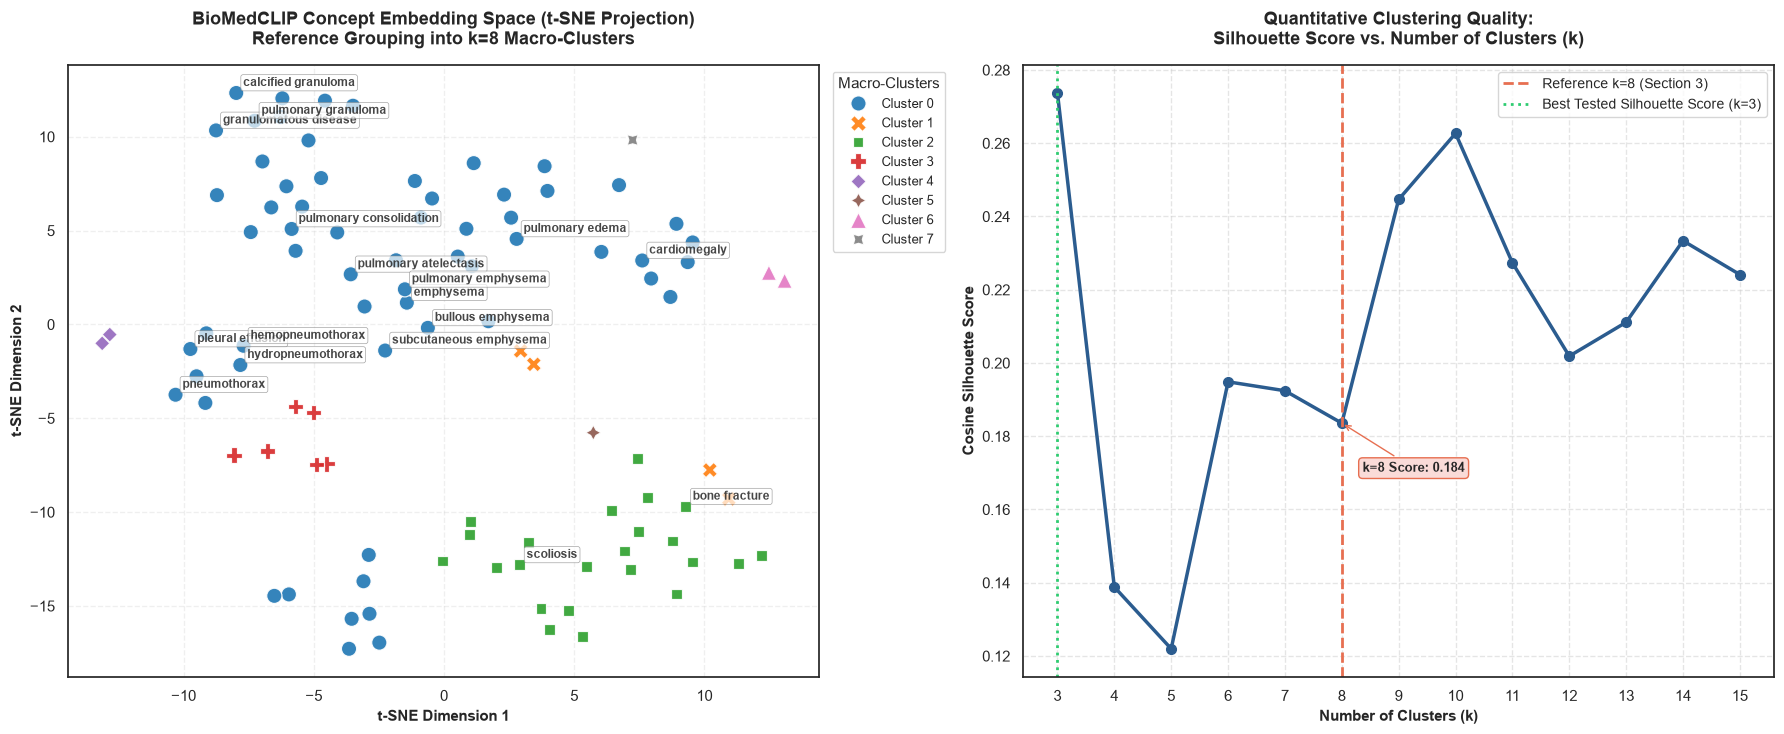

In [10]:
# Project the reference k=8 grouping; score selection uses the original embeddings.
tsne = TSNE(
    n_components=2,
    perplexity=min(15, len(validation_embeddings) - 1),
    random_state=42,
    metric="cosine",
)
embeddings_2d = tsne.fit_transform(validation_embeddings)
validation_plot_df = validation_hierarchy_df.copy()
validation_plot_df["tsne_x"] = embeddings_2d[:, 0]
validation_plot_df["tsne_y"] = embeddings_2d[:, 1]
validation_plot_df["cluster_label"] = validation_plot_df["macro_cluster"].map(
    lambda cluster: f"Cluster {int(cluster)}"
)
cluster_order = [
    f"Cluster {int(cluster)}"
    for cluster in sorted(validation_plot_df["macro_cluster"].unique())
]
palette = dict(zip(cluster_order, sns.color_palette("tab10", len(cluster_order))))

annotated_concepts = [
    "cardiomegaly", "pleural effusion", "pneumothorax", "pulmonary edema",
    "fracture", "granuloma", "atelectasis", "scoliosis", "emphysema",
    "consolidation",
]

with sns.axes_style("white"), sns.plotting_context("notebook"):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
    sns.scatterplot(
        data=validation_plot_df,
        x="tsne_x", y="tsne_y",
        hue="cluster_label", hue_order=cluster_order,
        style="cluster_label", style_order=cluster_order,
        palette=palette, s=120, alpha=0.9,
        ax=axes[0], legend="full",
    )
    axes[0].set_title(
        "BioMedCLIP Concept Embedding Space (t-SNE Projection)\n"
        "Reference Grouping into k=8 Macro-Clusters",
        fontsize=13, fontweight="bold", pad=15,
    )
    axes[0].set_xlabel("t-SNE Dimension 1", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("t-SNE Dimension 2", fontsize=11, fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.3)

    for _, row in validation_plot_df.iterrows():
        concept_name = str(row["parent_concept"]).lower()
        if any(term in concept_name for term in annotated_concepts):
            axes[0].annotate(
                row["parent_concept"], (row["tsne_x"], row["tsne_y"]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=8.5, fontweight="bold", alpha=0.85,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5, alpha=0.7),
            )

    axes[0].legend(
        loc="upper left", bbox_to_anchor=(1.01, 1),
        title="Macro-Clusters", title_fontsize=11, fontsize=9.5,
    )

    axes[1].plot(
        k_range, silhouette_scores, marker="o", linewidth=2.5,
        color="#2B5C8F", markersize=7,
    )
    axes[1].axvline(
        x=reference_k, color="#E76F51", linestyle="--", linewidth=2,
        label="Reference k=8 (Section 3)",
    )
    axes[1].axvline(
        x=optimal_k, color="#2ECC71", linestyle=":", linewidth=2,
        label=f"Best Tested Silhouette Score (k={optimal_k})",
    )
    axes[1].set_title(
        "Quantitative Clustering Quality:\nSilhouette Score vs. Number of Clusters (k)",
        fontsize=13, fontweight="bold", pad=15,
    )
    axes[1].set_xlabel("Number of Clusters (k)", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("Cosine Silhouette Score", fontsize=11, fontweight="bold")
    axes[1].set_xticks(k_range)
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend(loc="best", fontsize=10)
    axes[1].annotate(
        f"k=8 Score: {score_at_8:.3f}",
        xy=(reference_k, score_at_8), xytext=(15, -35),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="#E76F51"),
        fontsize=9.5, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FADBD8", ec="#E76F51", lw=1),
    )
    plt.tight_layout()
    plt.show()


## 3. Hierarchical Concept Analysis & Macro-Clusters

To evaluate our model beyond strict, fine-grained text matching, we introduce a **hierarchical clustering extension**. We apply **Agglomerative Clustering** with cosine metric and average linkage directly on the BioMedCLIP concept embeddings from Step 02, grouping the fine-grained dictionary artifacts into **8 distinct macro-clusters**.

This hierarchical grouping allows us to bridge the semantic gap, verifying whether the SAE captures the correct macro-category of a clinical finding even when the exact phrasing differs or is marked as *Uncertain*.

In [12]:
N_CLUSTERS = 8

hierarchy_df, parent_embeddings = build_concept_hierarchy(
    dict_dir, n_clusters=N_CLUSTERS
)
display(hierarchy_df.head())

Created 8 clinical macro-cluster for the 100 concepts.


,parent_concept,macro_cluster
0,lung,0
1,lung opacity,0
2,cardiomegaly,0
3,calcinosis,2
4,pulmonary atelectasis,0


### Note on Cluster Activation and Sparsity

Although the hierarchical clustering function is configured to generate **8 distinct macro-clusters** (`n_clusters=8`), the evaluation table and plots may display a smaller subset (e.g., 6 active clusters).

This behavior is a direct consequence of the **extreme sparsity enforced by the Sparse Autoencoder (SAE)**. When evaluating a limited subset of images (e.g., `NUM_SAMPLES = 10`), only a fraction of the latent features are triggered. Consequently, concepts belonging to certain macro-categories receive zero activations in this specific batch, highlighting the selective and sparse nature of the learned representations rather than an algorithmic limitation.

### Aggregation over Semantic Macro-Clusters

To analyze the performance at a coarser granularity, we map individual concept verdicts (*Aligned*, *Unaligned*, *Uncertain*) back to their parent concepts and subsequently to their assigned **macro-cluster**. This maps fine-grained model activations to broader clinical families, evaluating whether the latent representations target the correct anatomical or pathological domains.

Before scanning the dataset, two fast-access Python dictionaries are instantiated to optimize lookup speeds:

* **`parent_to_cluster`**: Maps each canonical parent concept (e.g., `"cardiomegaly"`) directly to its assigned macro-cluster ID derived from Agglomerative Clustering (e.g., `Cluster 2`).
* **`phrase_to_parent`**: Connects each specific fine-grained descriptive phrase or synonym from the Step 02 dictionary back to its broader parent concept.

The script iterates through all evaluated images and their corresponding Sparse Autoencoder (SAE) concepts, executing a two-step semantic resolution:

* **Phrase-to-Parent Resolution**: `parent = phrase_to_parent.get(concept_text, concept_text)` retrieves the core medical concept underlying the specific phrase text.
* **Parent-to-Cluster Mapping**: `cluster = parent_to_cluster.get(parent, -1)` assigns the corresponding macro-cluster ID to that parent concept.

Successfully matched entries are appended to an `all_details` list as structured dictionary records containing the image index, the concept string, the MedGemma evaluation verdict (*Aligned*, *Unaligned*, or *Uncertain*), and the target macro-cluster ID.

The collected record collection is converted into a Pandas DataFrame (`df_details`) to execute the final aggregation:

* **Grouping & Counting**: `.groupby(['macro_cluster', 'verdict']).size()` tallies the frequency of each verification outcome across individual macro-clusters.
* **Table Pivoting**: `.unstack(fill_value=0)` reshapes the output into a cross-tabulation format where rows represent clinical macro-clusters and columns correspond to evaluation verdicts.
* **Percentage Normalization**: `.div(..., axis=0) * 100` converts absolute category counts into relative row-wise percentages, generating the normalized data structure required for the stacked bar visualizations and summary tables.

In [14]:
def analyze_macro_clusters_from_df(
    df_eval, hierarchy_df, phrase_metadata, benchmark_name=""
):
  """Aggrega i risultati sui macro-cluster a partire dal DataFrame di valutazione

  e mostra la tabella percentuale.
  """
  parent_to_cluster = {
      str(row["parent_concept"]).strip().lower(): row["macro_cluster"]
      for _, row in hierarchy_df.iterrows()
  }

  phrase_to_parent = dict(
      zip(
          phrase_metadata["text"].str.strip().str.lower(),
          phrase_metadata["parent_concept"].str.strip().str.lower(),
      )
  )

  all_details = []
  # Itera sui record del DataFrame salvato
  for res in df_eval.to_dict("records"):
    img_idx = res["image_index"]
    for detail in res["details"]:
      concept_text = str(detail["concept"]).strip().lower()
      verdict = detail["verdict"]

      parent = phrase_to_parent.get(concept_text, concept_text)
      cluster = parent_to_cluster.get(parent, -1)

      if cluster != -1:
        all_details.append({
            "image_index": img_idx,
            "concept": concept_text,
            "verdict": verdict,
            "macro_cluster": cluster,
        })

  df_details = pd.DataFrame(all_details)

  cluster_eval = (
      df_details.groupby(["macro_cluster", "verdict"])
      .size()
      .unstack(fill_value=0)
  )

  for col in ["Aligned", "Unaligned", "Uncertain"]:
    if col not in cluster_eval.columns:
      cluster_eval[col] = 0
  cluster_eval = cluster_eval[["Aligned", "Unaligned", "Uncertain"]]

  cluster_eval_pct = cluster_eval.div(cluster_eval.sum(axis=1), axis=0) * 100

  print(
      f"\nPerformance sui {hierarchy_df['macro_cluster'].nunique()}"
      f" Macro-Cluster Clinici ({benchmark_name}) (%):"
  )
  display(cluster_eval_pct.round(2))

  return df_details, cluster_eval_pct

In [16]:
sample_benchmarks = [50, 100, 500]

for n in sample_benchmarks:
  csv_path = os.path.join(save_dir, f"df_evaluation_{n}_samples.csv")
  if not os.path.exists(csv_path):
    print(f"File per N={n} non trovato, salto.")
    continue

  df_eval_current = pd.read_csv(csv_path)

  if "details" in df_eval_current.columns:
    df_eval_current["details"] = df_eval_current["details"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

  df_details_n, cluster_pct_n = analyze_macro_clusters_from_df(
      df_eval=df_eval_current,
      hierarchy_df=hierarchy_df,
      phrase_metadata=phrase_metadata,
      benchmark_name=f"N={n}",
  )

  df_details_n.to_csv(f"{save_dir}/df_details_{n}_samples.csv", index=False)


Performance sui 8 Macro-Cluster Clinici (N=50) (%):


verdict,Aligned,Unaligned,Uncertain
macro_cluster,,,
0,6.64,18.60,74.75
1,2.00,24.00,74.00
2,4.48,22.39,73.13
3,11.76,29.41,58.82
4,71.43,7.14,21.43
5,0.00,25.81,74.19
7,0.00,25.00,75.00



Performance sui 8 Macro-Cluster Clinici (N=100) (%):


verdict,Aligned,Unaligned,Uncertain
macro_cluster,,,
0,6.53,18.73,74.74
1,4.12,22.68,73.20
2,4.29,20.71,75.00
3,6.00,34.00,60.00
4,58.62,3.45,37.93
5,0.00,27.59,72.41
6,0.00,0.00,100.00
7,0.00,20.00,80.00



Performance sui 8 Macro-Cluster Clinici (N=500) (%):


verdict,Aligned,Unaligned,Uncertain
macro_cluster,,,
0,6.64,21.05,72.31
1,0.79,26.48,72.73
2,4.01,20.34,75.65
3,3.65,39.73,56.62
4,53.21,4.59,42.20
5,0.00,22.26,77.74
6,10.00,10.00,80.00
7,1.33,25.33,73.33


DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (N=50)
Total Macro-Clusters Analyzed: 7
Total Concepts Mapped:         484


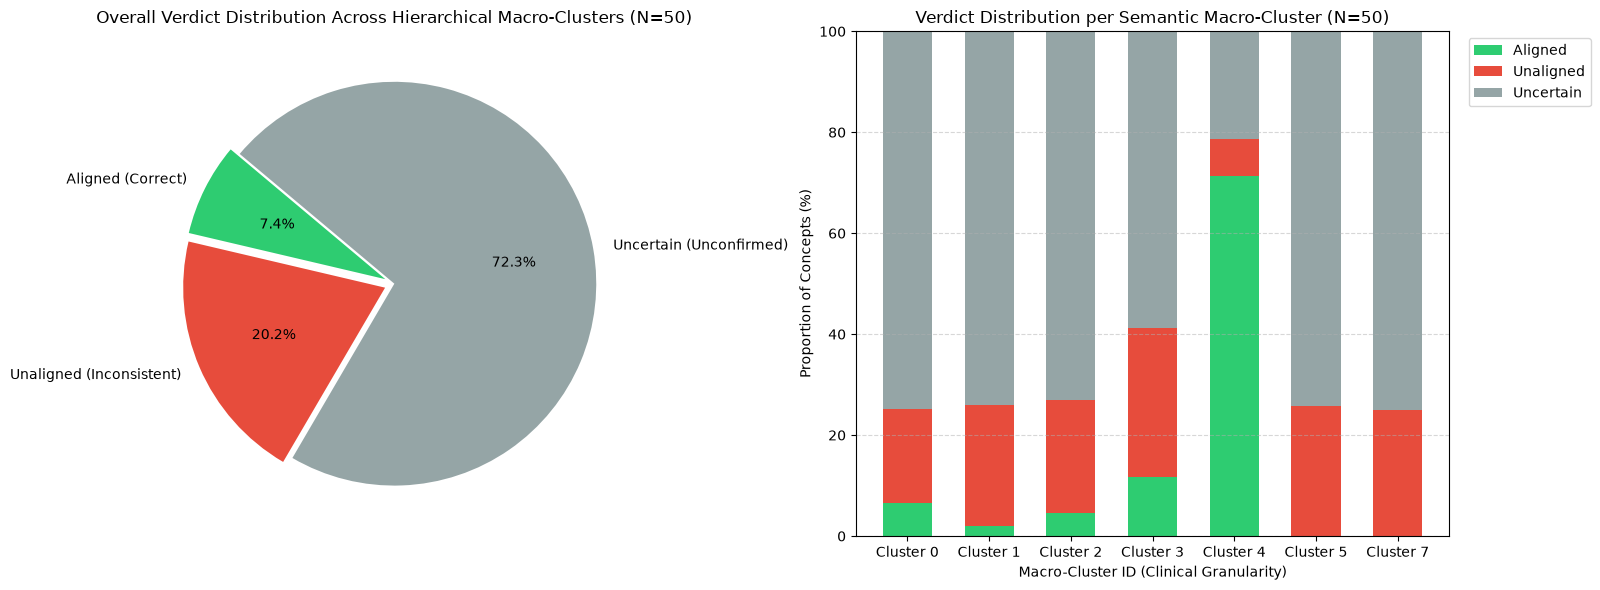

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (N=100)
Total Macro-Clusters Analyzed: 8
Total Concepts Mapped:         968


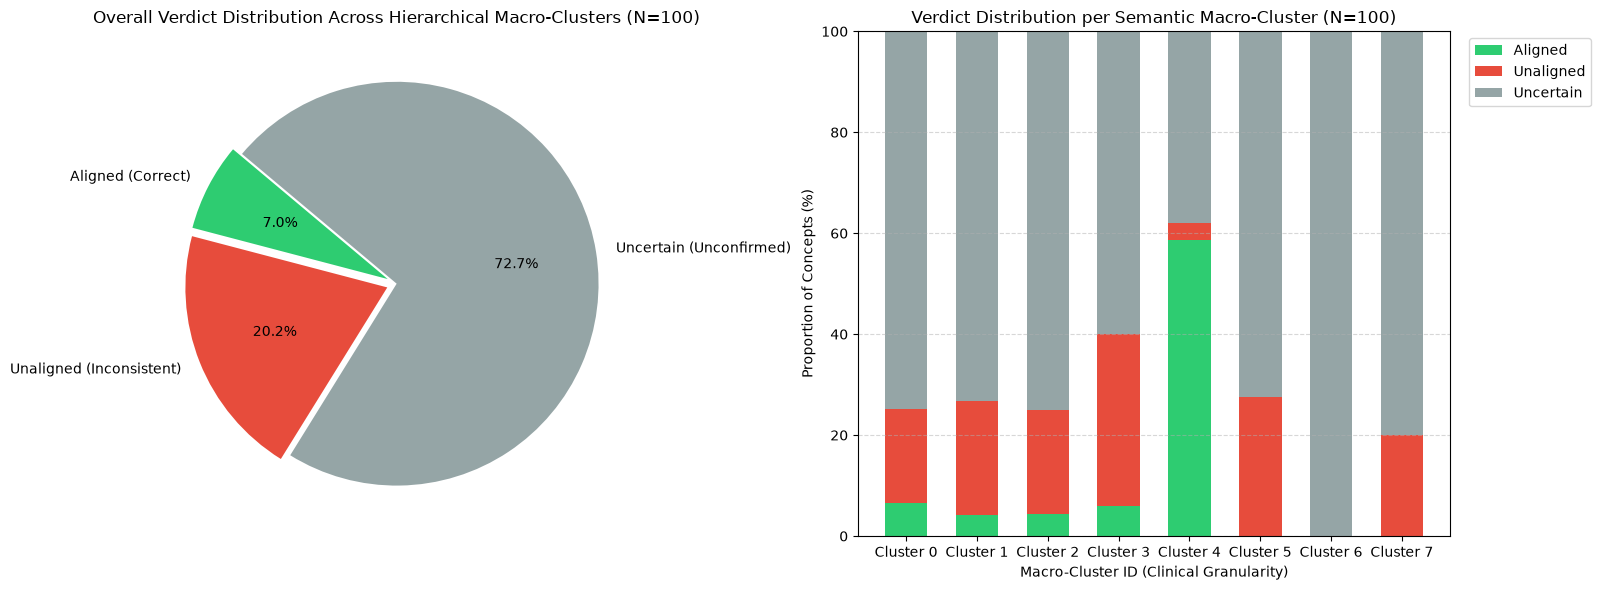

DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION) (N=500)
Total Macro-Clusters Analyzed: 8
Total Concepts Mapped:         4811


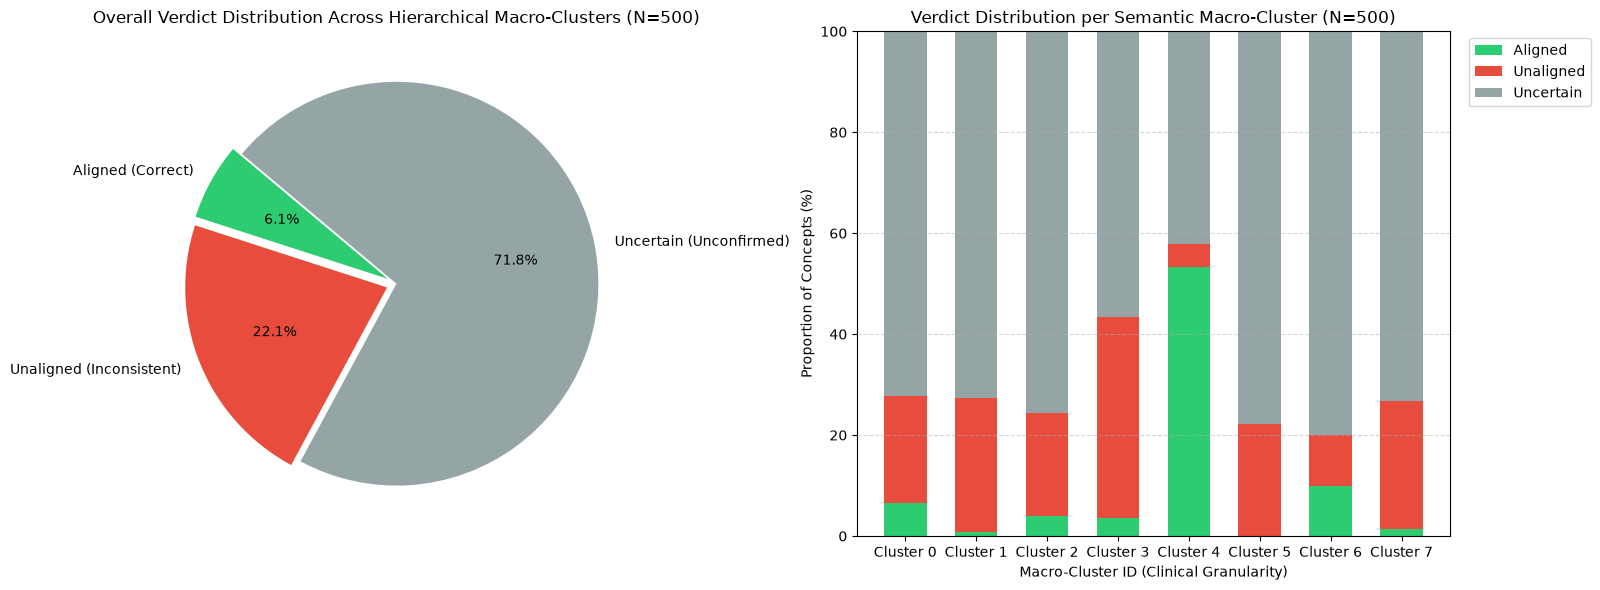

In [17]:
def plot_and_print_macro_clusters(df_details, benchmark_name=""):
  """Stampa l'analisi quantitativa dei macro-cluster e genera i due grafici

  (Torta della distribuzione globale sui cluster + Barre impilate per cluster).
  """
  if df_details.empty:
    print(f"[{benchmark_name}] Nessun dato disponibile per i macro-cluster.")
    return

  cluster_eval_counts = (
      df_details.groupby(["macro_cluster", "verdict"])
      .size()
      .unstack(fill_value=0)
  )

  for v in ["Aligned", "Unaligned", "Uncertain"]:
    if v not in cluster_eval_counts.columns:
      cluster_eval_counts[v] = 0
  cluster_eval_counts = cluster_eval_counts[
      ["Aligned", "Unaligned", "Uncertain"]
  ]

  cluster_eval_pct = (
      cluster_eval_counts.div(cluster_eval_counts.sum(axis=1), axis=0) * 100
  )

  print("=" * 65)
  print(
      "DETAILED QUANTITATIVE ANALYSIS PER MACRO-CLUSTER (HIERARCHICAL EXTENSION)"
      f" ({benchmark_name})"
  )
  print("=" * 65)
  print(f"Total Macro-Clusters Analyzed: {len(cluster_eval_pct)}")
  print(f"Total Concepts Mapped:         {len(df_details)}")
  print("=" * 65)

  fig, axes = plt.subplots(1, 2, figsize=(16, 6))

  # Plot 1: Pie Chart globale sui cluster
  global_cluster_scores = cluster_eval_counts.sum(axis=0) / len(df_details)
  labels = [
      "Aligned (Correct)",
      "Unaligned (Inconsistent)",
      "Uncertain (Unconfirmed)",
  ]
  colors = ["#2ecc71", "#e74c3c", "#95a5a6"]
  explode = (0.05, 0.05, 0)

  axes[0].pie(
      global_cluster_scores,
      labels=labels,
      autopct="%1.1f%%",
      colors=colors,
      startangle=140,
      explode=explode,
  )
  axes[0].set_title(
      "Overall Verdict Distribution Across Hierarchical Macro-Clusters"
      f" ({benchmark_name})"
  )

  # Plot 2: Stacked Bar Chart per macro-cluster
  cluster_indices = [f"Cluster {int(c)}" for c in cluster_eval_pct.index]
  bar_aligned = cluster_eval_pct["Aligned"].values
  bar_unaligned = cluster_eval_pct["Unaligned"].values
  bar_uncertain = cluster_eval_pct["Uncertain"].values

  x_pos = np.arange(len(cluster_indices))

  axes[1].bar(x_pos, bar_aligned, label="Aligned", color="#2ecc71", width=0.6)
  axes[1].bar(
      x_pos,
      bar_unaligned,
      bottom=bar_aligned,
      label="Unaligned",
      color="#e74c3c",
      width=0.6,
  )
  axes[1].bar(
      x_pos,
      bar_uncertain,
      bottom=bar_aligned + bar_unaligned,
      label="Uncertain",
      color="#95a5a6",
      width=0.6,
  )

  axes[1].set_xticks(x_pos)
  axes[1].set_xticklabels(cluster_indices, rotation=0)
  axes[1].set_xlabel("Macro-Cluster ID (Clinical Granularity)")
  axes[1].set_ylabel("Proportion of Concepts (%)")
  axes[1].set_title(
      f"Verdict Distribution per Semantic Macro-Cluster ({benchmark_name})"
  )
  axes[1].legend(loc="upper right", bbox_to_anchor=(1.25, 1))
  axes[1].grid(axis="y", linestyle="--", alpha=0.5)
  axes[1].set_ylim(0, 100)

  plt.tight_layout()
  plt.show()

for n in sample_benchmarks:
  details_csv_path = os.path.join(save_dir, f"df_details_{n}_samples.csv")

  if not os.path.exists(details_csv_path):
    print(
        f"File {details_csv_path} non trovato. Esegui prima l'aggregazione"
        " gerarchica."
    )
    continue

  df_details_current = pd.read_csv(details_csv_path)


  plot_and_print_macro_clusters(df_details_current, benchmark_name=f"N={n}")